# **Molecular Descriptor Extraction and Clustering**

- Author: Tales Miguel Machado Pereira
- RA: 140247
- Professor: Dr. Marcos Quiles

This notebook extracts 6 key molecular descriptors from SMILES representations and performs clustering analysis using K-Means and DBSCAN algorithms on the QM9 dataset.

### **1. Import Libraries**

Import necessary libraries for molecular descriptor calculation and data analysis. Polars is used for optimized data processing where possible, with pandas fallback for RDKit compatibility.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from tqdm.auto import tqdm

# RDKit for molecular descriptors
from rdkit import Chem
from rdkit.Chem import Descriptors, rdMolDescriptors, Fragments, Lipinski, Crippen
from rdkit.Chem.rdMolDescriptors import CalcNumRotatableBonds, CalcNumHBD, CalcNumHBA

# Clustering libraries
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import hdbscan

from scipy import stats

### **2. Load Molecular Data**

Load the QM9 dataset with SMILES strings from the previously processed data.

In [2]:
df_pl = pl.read_csv('qm9_complete_dataset.csv')
df = df_pl.to_pandas()  # Convert to pandas for RDKit compatibility

print(f"Dataset loaded with {len(df)} molecules")
print(f"Columns: {list(df.columns)}")

# SMILES Validation
valid_smiles = []
valid_indices = []

for idx, smiles in tqdm(enumerate(df['canonical_smiles']), total=len(df), desc="Validating SMILES"):
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        valid_smiles.append(smiles)
        valid_indices.append(idx)

print(f"\nValid SMILES for descriptor calculation: {len(valid_smiles)}/{len(df)}")

# df with valid molecules only
df_valid_pl = df_pl.filter(pl.col('canonical_smiles').is_in(valid_smiles))
df_valid = df_valid_pl.to_pandas().reset_index(drop=True)
df_valid['smiles'] = valid_smiles

Dataset loaded with 133885 molecules
Columns: ['gdb_id', 'rot_const_A', 'rot_const_B', 'rot_const_C', 'dipole_moment', 'isotropic_polarizability', 'homo_energy', 'lumo_energy', 'homo_lumo_gap', 'electronic_spatial_extent', 'zpve', 'U0', 'U', 'H', 'G', 'Cv', 'n_atoms', 'smiles', 'canonical_smiles']


Validating SMILES: 100%|██████████| 133885/133885 [00:03<00:00, 43896.25it/s]




Valid SMILES for descriptor calculation: 133885/133885


### **3. Calculate Key Molecular Descriptors**

Calculating 6 molecular descriptors that capture these chemical features: size, lipophilicity, polarity, hydrogen bonding, and flexibility.

In [3]:
def calculate_key_descriptors(smiles_list):
    """Calculate 6 key molecular descriptors from SMILES (2D only, no geometry)."""
    
    descriptors = []
    
    for smiles in tqdm(smiles_list, desc="Calculating descriptors"):
        mol = Chem.MolFromSmiles(smiles)
        
        if mol is None:
            # Handle invalid SMILES
            desc = {
                'molecular_weight': np.nan,
                'logp': np.nan,
                'tpsa': np.nan,
                'hbd': np.nan,
                'hba': np.nan,
                'rotatable_bonds': np.nan
            }
        else:
            desc = {
                'molecular_weight': Descriptors.MolWt(mol),     # Size
                'logp': Crippen.MolLogP(mol),                   # Lipophilicity
                'tpsa': rdMolDescriptors.CalcTPSA(mol),         # Polarity
                'hbd': CalcNumHBD(mol),                         # Hydrogen-bond donors
                'hba': CalcNumHBA(mol),                         # Hydrogen-bond acceptors
                'rotatable_bonds': CalcNumRotatableBonds(mol)   # Flexibility
            }
        
        descriptors.append(desc)
    
    # Create polars DataFrame for better performance
    descriptors_pl = pl.DataFrame(descriptors)
    return descriptors_pl

print("Calculating 6 key molecular descriptors...")
descriptors_df_pl = calculate_key_descriptors(df_valid['smiles'])
descriptors_df = descriptors_df_pl.to_pandas()  # Convert for compatibility

print(f"\nDescriptors calculated for {len(descriptors_df)} molecules")
print(f"Number of descriptors: {len(descriptors_df.columns)}")
print(f"Descriptor names: {list(descriptors_df.columns)}")

print("\nDescriptor statistics:")
print(descriptors_df.describe().round(3))

# Use polars for efficient data combination
base_cols_pl = df_valid_pl.select(['gdb_id', 'canonical_smiles']).with_columns(
    pl.Series('smiles', df_valid['smiles'])
)
combined_df_pl = pl.concat([base_cols_pl, descriptors_df_pl], how='horizontal')
combined_df = combined_df_pl.to_pandas()

print(f"\nCombined dataset shape: {combined_df.shape}")
print(f"Missing values per descriptor:")
# Use polars for efficient null counting
descriptor_cols = descriptors_df_pl.columns
missing_summary_pl = combined_df_pl.select([pl.col(col).null_count().alias(f"{col}_nulls") for col in descriptor_cols])
missing_dict = {col.replace('_nulls', ''): missing_summary_pl[col][0] for col in missing_summary_pl.columns if missing_summary_pl[col][0] > 0}
for col, count in missing_dict.items():
    print(f"  {col}: {count}")
if not missing_dict:
    print("  No missing values found")

Calculating 6 key molecular descriptors...


Calculating descriptors: 100%|██████████| 133885/133885 [00:19<00:00, 6858.48it/s]




Descriptors calculated for 133885 molecules
Number of descriptors: 6
Descriptor names: ['molecular_weight', 'logp', 'tpsa', 'hbd', 'hba', 'rotatable_bonds']

Descriptor statistics:
       molecular_weight        logp        tpsa         hbd         hba  \
count        133885.000  133885.000  133885.000  133885.000  133885.000   
mean            122.765       0.297      37.164       0.828       2.232   
std               7.565       1.001      21.245       0.838       1.055   
min              16.043      -4.910       0.000       0.000       0.000   
25%             121.183      -0.349      20.310       0.000       2.000   
50%             125.127       0.282      35.820       1.000       2.000   
75%             127.143       0.947      50.620       1.000       3.000   
max             152.037       3.757     130.120       5.000       7.000   

       rotatable_bonds  
count       133885.000  
mean             0.923  
std              1.091  
min              0.000  
25%              

### **4. Visualize Descriptor Distribution**

Analyze the distribution of the two key molecular descriptors.

Clean dataset for clustering: 133885 molecules
Total number of descriptors: 6
Descriptor names: ['molecular_weight', 'logp', 'tpsa', 'hbd', 'hba', 'rotatable_bonds']

Feature Space Information:
Number of samples (molecules): 133885
Number of features (descriptors): 6
Feature vector shape: (133885, 6)


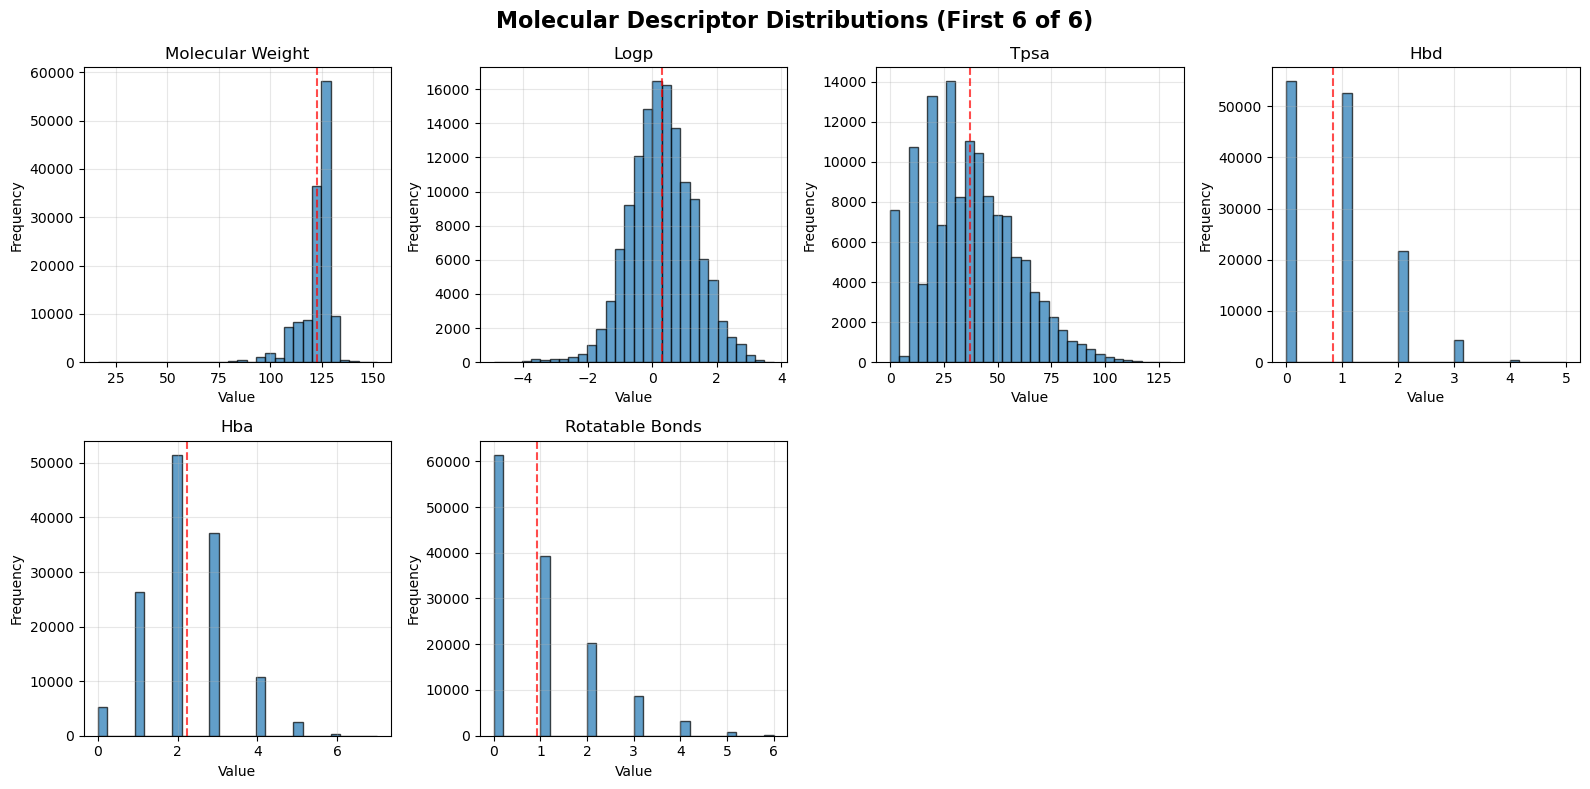


Feature matrix created:
  Shape: (133885, 6)
  Data type: float64
  Memory usage: 6.13 MB

Feature ranges (first 10 descriptors):
  molecular_weight: 16.04 to 152.04 (mean: 122.76)
  logp: -4.91 to 3.76 (mean: 0.30)
  tpsa: 0.00 to 130.12 (mean: 37.16)
  hbd: 0.00 to 5.00 (mean: 0.83)
  hba: 0.00 to 7.00 (mean: 2.23)
  rotatable_bonds: 0.00 to 6.00 (mean: 0.92)


In [4]:
# Get all descriptor columns (excluding ID and SMILES columns)
descriptor_columns = [col for col in combined_df.columns if col not in ['gdb_id', 'smiles', 'canonical_smiles']]

# Use polars for efficient data cleaning
clean_df_pl = combined_df_pl.drop_nulls(subset=descriptor_columns)
clean_df = clean_df_pl.to_pandas().reset_index(drop=True)
print(f"Clean dataset for clustering: {len(clean_df)} molecules")
print(f"Total number of descriptors: {len(descriptor_columns)}")
print(f"Descriptor names: {descriptor_columns}")

# Show some key statistics about the feature space
print(f"\nFeature Space Information:")
print(f"Number of samples (molecules): {len(clean_df)}")
print(f"Number of features (descriptors): {len(descriptor_columns)}")
print(f"Feature vector shape: ({len(clean_df)}, {len(descriptor_columns)})")

# Visualize distributions of key descriptors
key_descriptors = descriptor_columns[:12]  # Show first 12 descriptors
n_descriptors = len(key_descriptors)
n_cols = 4
n_rows = (n_descriptors + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten() if n_rows > 1 else axes if n_rows == 1 else [axes]

for i, desc in enumerate(key_descriptors):
    data = clean_df[desc].dropna()
    
    if len(data) > 0:
        axes[i].hist(data, bins=30, alpha=0.7, edgecolor='black')
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Frequency')
        axes[i].set_title(f'{desc.replace("_", " ").title()}')
        axes[i].grid(True, alpha=0.3)
        
        # Add mean line
        mean_val = data.mean()
        axes[i].axvline(mean_val, color='red', linestyle='--', alpha=0.7)
    else:
        axes[i].text(0.5, 0.5, 'No data', transform=axes[i].transAxes, ha='center', va='center')
        axes[i].set_title(f'{desc} (No Data)')

# Hide unused subplots
for i in range(len(key_descriptors), len(axes)):
    axes[i].set_visible(False)

plt.suptitle(f'Molecular Descriptor Distributions (First {len(key_descriptors)} of {len(descriptor_columns)})', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Prepare feature matrix for clustering (all descriptors)
feature_matrix = clean_df[descriptor_columns].values
print(f"\nFeature matrix created:")
print(f"  Shape: {feature_matrix.shape}")
print(f"  Data type: {feature_matrix.dtype}")
print(f"  Memory usage: {feature_matrix.nbytes / 1024 / 1024:.2f} MB")

# Show feature ranges
print(f"\nFeature ranges (first 10 descriptors):")
for i, desc in enumerate(descriptor_columns[:10]):
    min_val = clean_df[desc].min()
    max_val = clean_df[desc].max()
    mean_val = clean_df[desc].mean()
    print(f"  {desc}: {min_val:.2f} to {max_val:.2f} (mean: {mean_val:.2f})")

if len(descriptor_columns) > 10:
    print(f"  ... and {len(descriptor_columns) - 10} more descriptors")

### **5. Data Preparation for Clustering**

Standardize the features for optimal clustering performance.

In [5]:
# Standardize features for clustering
scaler = StandardScaler()
features_scaled = scaler.fit_transform(feature_matrix)

print("Feature standardization completed")
print(f"Scaled features shape: {features_scaled.shape}")
print(f"\nScaled feature statistics:")
print(f"  Mean: {features_scaled.mean(axis=0)}")
print(f"  Std: {features_scaled.std(axis=0)}")

# Create DataFrame with scaled features for easier handling
scaled_df = clean_df.copy()
scaled_df['logp_scaled'] = features_scaled[:, 0]
scaled_df['tpsa_scaled'] = features_scaled[:, 1]

print("\nData ready for clustering analysis")

Feature standardization completed
Scaled features shape: (133885, 6)

Scaled feature statistics:
  Mean: [-1.60656905e-15 -5.43448304e-17 -1.76620699e-16  9.68017291e-17
  8.49137975e-17 -4.07586228e-17]
  Std: [1. 1. 1. 1. 1. 1.]

Data ready for clustering analysis


### **6. K-Means Clustering**

Apply K-Means clustering algorithm to group molecules based on their descriptors.


Performing K-Means clustering with different k values:

K-Means with k=2:
  Silhouette score: 0.293
  Cluster distribution:
    Cluster 0: 76450 molecules (57.1%)
    Cluster 1: 57435 molecules (42.9%)

K-Means with k=2:
  Silhouette score: 0.293
  Cluster distribution:
    Cluster 0: 76450 molecules (57.1%)
    Cluster 1: 57435 molecules (42.9%)

K-Means with k=3:
  Silhouette score: 0.205
  Cluster distribution:
    Cluster 0: 59350 molecules (44.3%)
    Cluster 1: 42544 molecules (31.8%)
    Cluster 2: 31991 molecules (23.9%)

K-Means with k=3:
  Silhouette score: 0.205
  Cluster distribution:
    Cluster 0: 59350 molecules (44.3%)
    Cluster 1: 42544 molecules (31.8%)
    Cluster 2: 31991 molecules (23.9%)

K-Means with k=5:
  Silhouette score: 0.235
  Cluster distribution:
    Cluster 0: 14067 molecules (10.5%)
    Cluster 1: 27321 molecules (20.4%)
    Cluster 2: 20465 molecules (15.3%)
    Cluster 3: 27925 molecules (20.9%)
    Cluster 4: 44107 molecules (32.9%)

K-Means with 

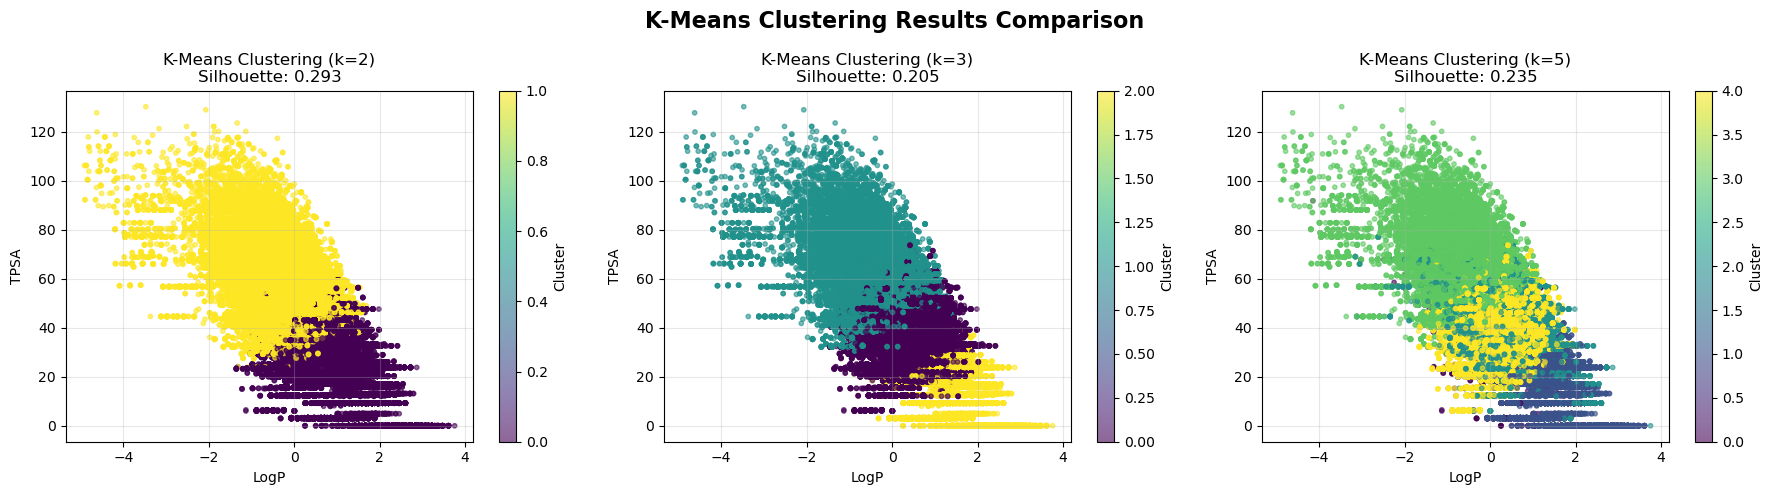


Using k=3 for final clustering analysis
Final cluster distribution:
  Cluster 0: 59350 molecules (44.3%)
  Cluster 1: 42544 molecules (31.8%)
  Cluster 2: 31991 molecules (23.9%)


In [6]:
# Perform K-Means clustering with k=2, k=3, and k=5
k_values = [2, 3, 5]
kmeans_results = {}

print("\nPerforming K-Means clustering with different k values:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(features_scaled)
    kmeans_results[k] = {
        'model': kmeans,
        'labels': labels,
        'silhouette': silhouette_score(features_scaled, labels)
    }

    unique_clusters, cluster_counts = np.unique(labels, return_counts=True)
    cluster_counts_dict = dict(zip(unique_clusters, cluster_counts))

    print(f"\nK-Means with k={k}:")
    print(f"  Silhouette score: {kmeans_results[k]['silhouette']:.3f}")
    print(f"  Cluster distribution:")
    for cluster, count in cluster_counts_dict.items():
        percentage = (count / len(labels)) * 100
        print(f"    Cluster {cluster}: {count} molecules ({percentage:.1f}%)")

# Plot clustering results for k=2, k=3, and k=5
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(k_values):
    labels = kmeans_results[k]['labels']
    scatter = axes[i].scatter(scaled_df['logp'], scaled_df['tpsa'], 
                             c=labels, cmap='viridis', alpha=0.6, s=10)
    axes[i].set_xlabel('LogP')
    axes[i].set_ylabel('TPSA')
    axes[i].set_title(f'K-Means Clustering (k={k})\nSilhouette: {kmeans_results[k]["silhouette"]:.3f}')
    axes[i].grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=axes[i], label='Cluster')

plt.suptitle('K-Means Clustering Results Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Use k=3 as the final clustering result for further analysis
kmeans_final = kmeans_results[3]['model']
kmeans_labels = kmeans_results[3]['labels']

# Add cluster labels to dataframe
scaled_df['kmeans_cluster'] = kmeans_labels

print(f"\nUsing k=3 for final clustering analysis")
print(f"Final cluster distribution:")
unique_clusters, cluster_counts = np.unique(kmeans_labels, return_counts=True)
cluster_counts_dict = dict(zip(unique_clusters, cluster_counts))
for cluster, count in cluster_counts_dict.items():
    percentage = (count / len(kmeans_labels)) * 100
    print(f"  Cluster {cluster}: {count} molecules ({percentage:.1f}%)")

### **7. HDBSCAN Clustering**

Apply HDBSCAN clustering algorithm as a hierarchical density-based alternative approach that better handles varying cluster densities in molecular data.

In [7]:
# HDBSCAN with Memory Management - Use Sampling Approach
print(f"Original dataset size: {len(features_scaled)} molecules")

# Sample a subset for HDBSCAN (20,000 molecules or 30% of dataset, whichever is smaller)
# HDBSCAN is more memory efficient than DBSCAN but still benefits from sampling on large datasets
sample_size = min(20000, int(0.3 * len(features_scaled)), len(features_scaled))
np.random.seed(42)  # For reproducibility
sample_indices = np.random.choice(len(features_scaled), size=sample_size, replace=False)

# Create sample dataset using polars for efficiency
features_sample = features_scaled[sample_indices]
# Create polars dataframe with row indices and filter
clean_df_with_idx_pl = clean_df_pl.with_row_count('row_idx')
clean_df_sample_pl = clean_df_with_idx_pl.filter(pl.col('row_idx').is_in(sample_indices)).drop('row_idx')
clean_df_sample = clean_df_sample_pl.to_pandas().reset_index(drop=True)

print(f"Sample size for HDBSCAN: {len(features_sample)} molecules")

Original dataset size: 133885 molecules
Sample size for HDBSCAN: 20000 molecules


### **7.1. Sample Representativeness Validation**

Validate that the sample is statistically representative (using Kolmogorov-Smirnov Test) of the full dataset before proceeding with HDBSCAN clustering.

Sample Quality Assessment:
Statistical Comparison (Full Dataset vs Sample):
Descriptor           Full Mean    Sample Mean  Diff %     Full Std     Sample Std  
--------------------------------------------------------------------------------


Comparing distributions: 100%|██████████| 6/6 [00:00<00:00, 1751.64it/s]


molecular_weight     122.765      122.717      0.04       7.565        7.634       
logp                 0.297        0.299        0.53       1.001        1.003       
tpsa                 37.164       37.151       0.04       21.245       21.294      
hbd                  0.828        0.826        0.24       0.838        0.840       
hba                  2.232        2.228        0.20       1.055        1.059       
rotatable_bonds      0.923        0.918        0.58       1.091        1.088       

Kolmogorov-Smirnov Test (p-value > 0.05 = good sample):


KS tests: 100%|██████████| 6/6 [00:00<00:00, 250.77it/s]

  molecular_weight    : p-value = 0.3656 (✓ Good)
  logp                : p-value = 0.9952 (✓ Good)
  tpsa                : p-value = 0.8087 (✓ Good)
  hbd                 : p-value = 0.9999 (✓ Good)
  hba                 : p-value = 0.9914 (✓ Good)
  rotatable_bonds     : p-value = 0.9735 (✓ Good)

Sample Quality Summary:
  Descriptors with good distribution match: 6/6
  Sample quality score: 100.0%
  Sample is highly representative of the full dataset


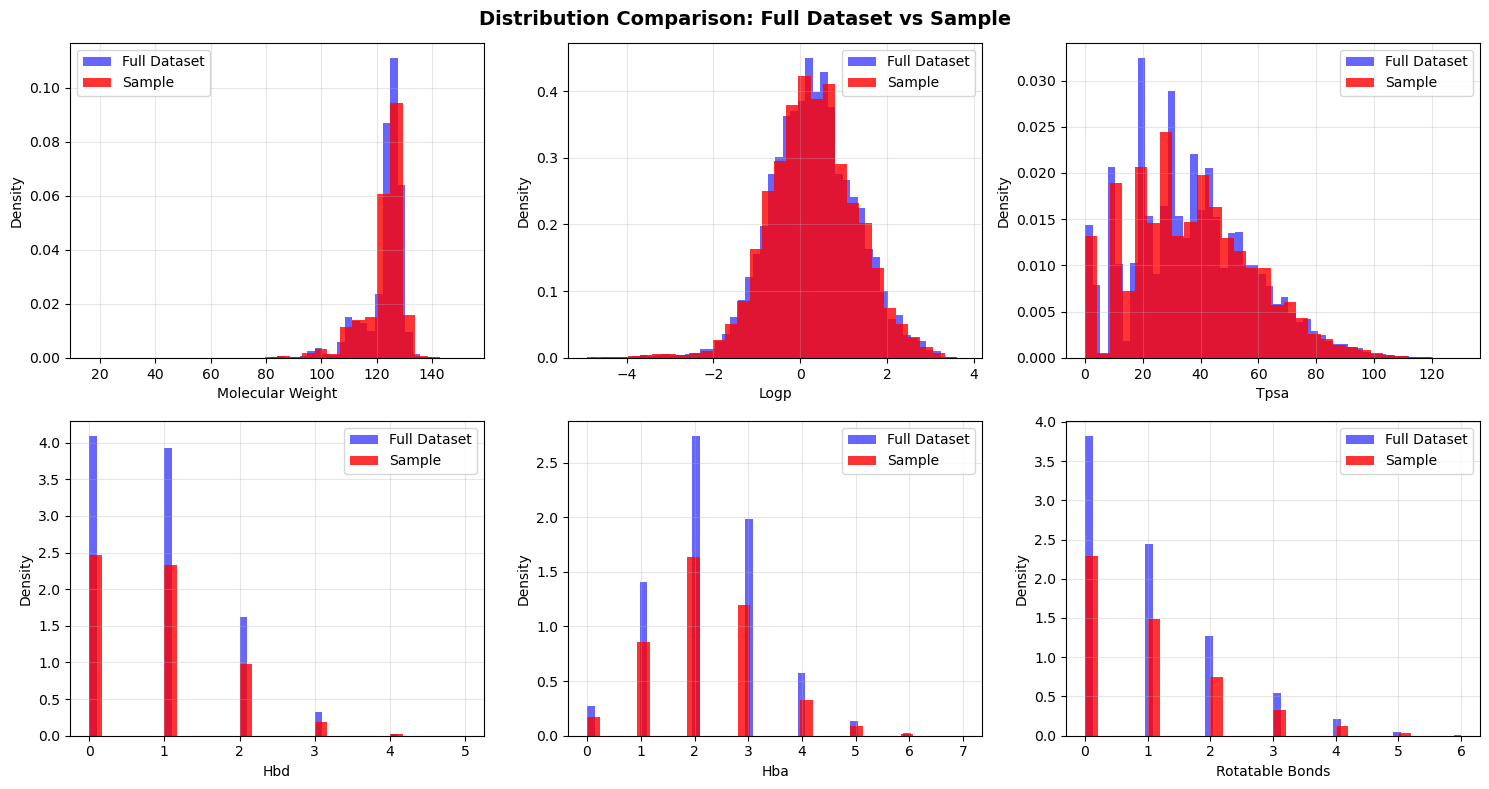

In [8]:
# Validate sample representativeness
print(f"Sample Quality Assessment:")
print("=" * 40)

# Compare distributions of each descriptor
descriptor_names = ['molecular_weight', 'logp', 'tpsa', 'hbd', 'hba', 'rotatable_bonds']

print("Statistical Comparison (Full Dataset vs Sample):")
print(f"{'Descriptor':<20} {'Full Mean':<12} {'Sample Mean':<12} {'Diff %':<10} {'Full Std':<12} {'Sample Std':<12}")
print("-" * 80)

for i, desc in enumerate(tqdm(descriptor_names, desc="Comparing distributions")):
    full_mean = clean_df[desc].mean()
    sample_mean = clean_df_sample[desc].mean()
    full_std = clean_df[desc].std()
    sample_std = clean_df_sample[desc].std()
    
    # Calculate percentage difference in means
    diff_percent = abs((sample_mean - full_mean) / full_mean) * 100 if full_mean != 0 else 0
    
    print(f"{desc:<20} {full_mean:<12.3f} {sample_mean:<12.3f} {diff_percent:<10.2f} {full_std:<12.3f} {sample_std:<12.3f}")

# Statistical tests for representativeness
print(f"\nKolmogorov-Smirnov Test (p-value > 0.05 = good sample):")
ks_results = []
for desc in tqdm(descriptor_names, desc="KS tests"):
    full_data = clean_df[desc].values
    sample_data = clean_df_sample[desc].values
    
    # KS test: null hypothesis = distributions are the same
    ks_stat, p_value = stats.ks_2samp(full_data, sample_data)
    ks_results.append(p_value)
    
    status = "✓ Good" if p_value > 0.05 else "⚠ Warning"
    print(f"  {desc:<20}: p-value = {p_value:.4f} ({status})")

# Overall assessment
good_samples = sum(1 for p in ks_results if p > 0.05)
total_descriptors = len(ks_results)
sample_quality = good_samples / total_descriptors

print(f"\nSample Quality Summary:")
print(f"  Descriptors with good distribution match: {good_samples}/{total_descriptors}")
print(f"  Sample quality score: {sample_quality:.1%}")

if sample_quality >= 0.8:
    print("  Sample is highly representative of the full dataset")
elif sample_quality >= 0.6:
    print("  Sample is moderately representative")
else:
    print("  Sample may not be representative (consider larger sample)")

# sample vs full distribution
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, desc in enumerate(descriptor_names):
    axes[i].hist(clean_df[desc], bins=50, alpha=0.6, label='Full Dataset', density=True, color='blue')
    axes[i].hist(clean_df_sample[desc], bins=30, alpha=0.8, label='Sample', density=True, color='red')
    axes[i].set_xlabel(desc.replace('_', ' ').title())
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribution Comparison: Full Dataset vs Sample', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### **7.2. HDBSCAN Parameter Optimization**

Optimize HDBSCAN parameters using the validated sample and apply the clustering algorithm.

In [9]:
# HDBSCAN Parameter Optimization
# HDBSCAN is much simpler - only needs min_cluster_size parameter
min_cluster_sizes = [5, 10, 15, 20, 25, 30]
min_samples_values = [5, 10, 15]  # For noise point detection

best_score = -1
best_params = {}
results = []

print("Optimizing HDBSCAN parameters on sample...")
# Create all parameter combinations for progress bar
param_combinations = [(min_cluster_size, min_samples) for min_cluster_size in min_cluster_sizes for min_samples in min_samples_values]

for min_cluster_size, min_samples in tqdm(param_combinations, desc="HDBSCAN optimization"):
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster_size, min_samples=min_samples, metric='euclidean')
    labels = clusterer.fit_predict(features_sample)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = list(labels).count(-1)
    
    if n_clusters > 1:  # Need at least 2 clusters for silhouette score
        try:
            # Only calculate silhouette for non-noise points
            valid_indices = labels != -1
            if np.sum(valid_indices) > 1:
                sil_score = silhouette_score(features_sample[valid_indices], labels[valid_indices])
                results.append({
                    'min_cluster_size': min_cluster_size,
                    'min_samples': min_samples,
                    'n_clusters': n_clusters, 
                    'n_noise': n_noise,
                    'silhouette': sil_score,
                    'cluster_persistence': np.mean(clusterer.cluster_persistence_) if len(clusterer.cluster_persistence_) > 0 else 0
                })
                
                if sil_score > best_score:
                    best_score = sil_score
                    best_params = {'min_cluster_size': min_cluster_size, 'min_samples': min_samples}
        except Exception as e:
            pass

# Display results using polars for better performance
results_df_pl = pl.DataFrame(results)
results_df = results_df_pl.to_pandas()
print(f"\nHDBSCAN parameter optimization results (on sample):")
print(results_df.round(3))

# Apply HDBSCAN with best parameters on SAMPLE ONLY
if best_params:
    print(f"\nBest parameters: min_cluster_size={best_params['min_cluster_size']}, min_samples={best_params['min_samples']}")
    print(f"Best silhouette score: {best_score:.3f}")
    
    hdbscan_final = hdbscan.HDBSCAN(
        min_cluster_size=best_params['min_cluster_size'], 
        min_samples=best_params['min_samples'],
        metric='euclidean'
    )
    hdbscan_labels_sample = hdbscan_final.fit_predict(features_sample)
else: 
    # Fallback parameters
    print(f"\nUsing fallback parameters: min_cluster_size=15, min_samples=10")
    hdbscan_final = hdbscan.HDBSCAN(min_cluster_size=15, min_samples=10, metric='euclidean')
    hdbscan_labels_sample = hdbscan_final.fit_predict(features_sample)

# Create HDBSCAN results for sample only
scaled_df_sample = clean_df_sample.copy()
scaled_df_sample['hdbscan_cluster'] = hdbscan_labels_sample

# Analyze HDBSCAN results on sample
n_clusters_hdbscan = len(set(hdbscan_labels_sample)) - (1 if -1 in hdbscan_labels_sample else 0)
n_noise_hdbscan = list(hdbscan_labels_sample).count(-1)

print(f"\nHDBSCAN clustering results (on sample of {sample_size} molecules):")
print(f"Number of clusters: {n_clusters_hdbscan}")
print(f"Number of noise points: {n_noise_hdbscan}")
print(f"Noise percentage: {(n_noise_hdbscan/len(hdbscan_labels_sample))*100:.1f}%")

# Display cluster persistence scores (HDBSCAN-specific feature)
if hasattr(hdbscan_final, 'cluster_persistence_') and len(hdbscan_final.cluster_persistence_) > 0:
    print(f"Cluster persistence scores: {hdbscan_final.cluster_persistence_.round(3)}")
    print(f"Average cluster persistence: {np.mean(hdbscan_final.cluster_persistence_):.3f}")

if n_clusters_hdbscan > 0:
    # Use numpy for efficient value counting
    unique_clusters, cluster_counts = np.unique(hdbscan_labels_sample, return_counts=True)
    cluster_counts_dict = dict(zip(unique_clusters, cluster_counts))
    print(f"\nCluster distribution:")
    for cluster, count in cluster_counts_dict.items():
        percentage = (count / len(hdbscan_labels_sample)) * 100
        if cluster == -1:
            print(f"  Noise: {count} molecules ({percentage:.1f}%)")
        else:
            print(f"  Cluster {cluster}: {count} molecules ({percentage:.1f}%)")

print(f"\nNote: HDBSCAN was run on a sample of {sample_size} molecules to manage memory usage.")
print("HDBSCAN provides hierarchical clustering with automatic density-based cluster detection.")

Optimizing HDBSCAN parameters on sample...


HDBSCAN optimization: 100%|██████████| 18/18 [00:36<00:00,  2.01s/it]




HDBSCAN parameter optimization results (on sample):
    min_cluster_size  min_samples  n_clusters  n_noise  silhouette  \
0                  5            5        1239     5828       0.600   
1                  5           10         547     6868       0.498   
2                  5           15         337     6384       0.404   
3                 10            5         638     5427       0.487   
4                 10           10         476     6797       0.495   
5                 10           15         283     6332       0.412   
6                 15            5         366     3838       0.365   
7                 15           10         310     5292       0.393   
8                 15           15         260     6265       0.404   
9                 20            5         256     3756       0.324   
10                20           10         217     4962       0.344   
11                20           15         198     5925       0.370   
12                25            5    

### **8. Clustering Results Visualization and Comparison**

Compare the results of both clustering algorithms and analyze cluster characteristics.

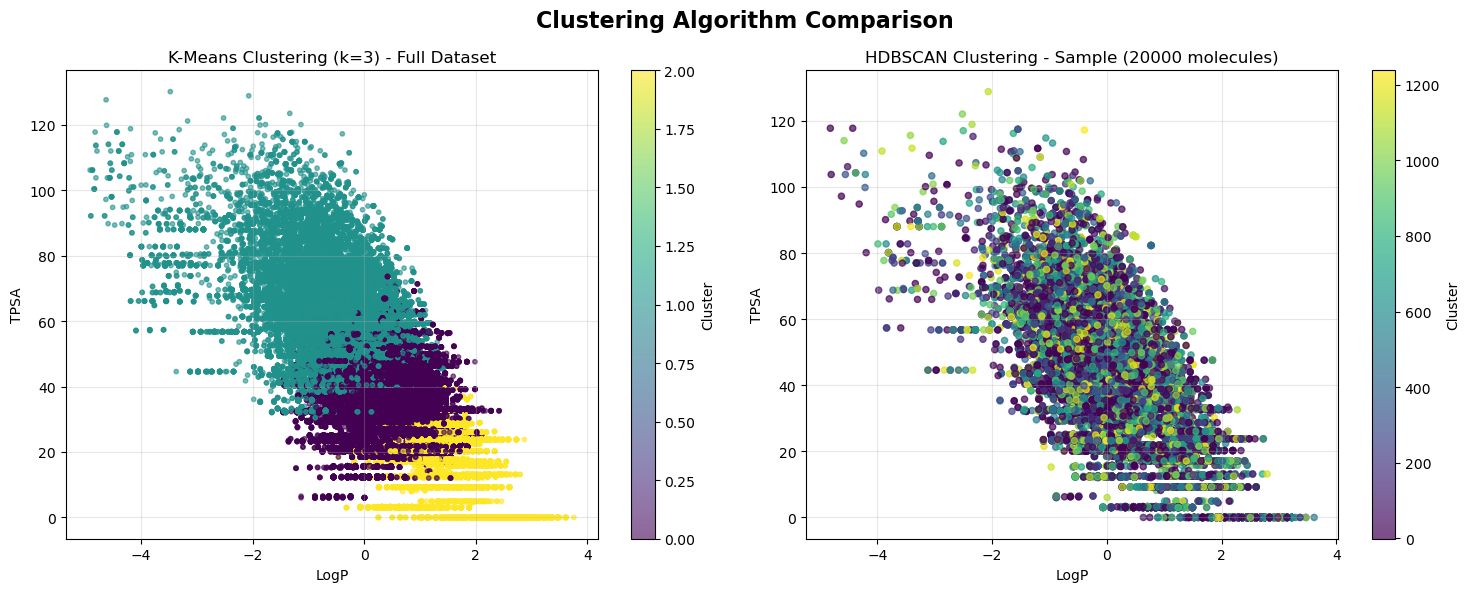

Clustering Algorithm Comparison:
K-Means (k=3) - Full Dataset:
  Dataset size: 133885 molecules
  Silhouette Score: 0.205
  Calinski-Harabasz Score: 48941.846
  Number of clusters: 3
K-Means (k=3) - Full Dataset:
  Dataset size: 133885 molecules
  Silhouette Score: 0.205
  Calinski-Harabasz Score: 48941.846
  Number of clusters: 3

HDBSCAN - Sample Dataset:
  Dataset size: 20000 molecules (sample)
  Silhouette Score: 0.600
  Calinski-Harabasz Score: 651.476
  Number of clusters: 1239
  Noise points: 5828 (29.1%)
  Average cluster persistence: 1.000

Cluster Characteristics Analysis:
K-Means Clusters (Full Dataset):
  Cluster 0 (n=59350):
    LogP: 0.34 ± 0.56
    TPSA: 33.36 ± 10.20
    Molecular Weight: 123.3 ± 6.3
  Cluster 1 (n=42544):
    LogP: -0.61 ± 0.76
    TPSA: 60.50 ± 14.72
    Molecular Weight: 125.1 ± 6.1
  Cluster 2 (n=31991):
    LogP: 1.43 ± 0.66
    TPSA: 13.19 ± 9.05
    Molecular Weight: 118.7 ± 9.6

HDBSCAN Clusters (Sample Dataset):
  Noise points (n=5828):
    Log

In [10]:
# Visualize clustering results
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# K-Means results (full dataset)
scatter1 = axes[0].scatter(scaled_df['logp'], scaled_df['tpsa'], 
                          c=scaled_df['kmeans_cluster'], cmap='viridis', 
                          alpha=0.6, s=10)
axes[0].set_xlabel('LogP')
axes[0].set_ylabel('TPSA')
axes[0].set_title(f'K-Means Clustering (k=3) - Full Dataset')
axes[0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# HDBSCAN results (sample only)
scatter2 = axes[1].scatter(scaled_df_sample['logp'], scaled_df_sample['tpsa'], 
                          c=scaled_df_sample['hdbscan_cluster'], cmap='viridis', 
                          alpha=0.7, s=20)
axes[1].set_xlabel('LogP')
axes[1].set_ylabel('TPSA')
axes[1].set_title(f'HDBSCAN Clustering - Sample ({sample_size} molecules)')
axes[1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[1], label='Cluster')

plt.suptitle('Clustering Algorithm Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Compare clustering performance
print("Clustering Algorithm Comparison:")
print("=" * 50)

# K-Means metrics (full dataset)
kmeans_silhouette = silhouette_score(features_scaled, kmeans_labels)
kmeans_calinski = calinski_harabasz_score(features_scaled, kmeans_labels)

print(f"K-Means (k=3) - Full Dataset:")
print(f"  Dataset size: {len(features_scaled)} molecules")
print(f"  Silhouette Score: {kmeans_silhouette:.3f}")
print(f"  Calinski-Harabasz Score: {kmeans_calinski:.3f}")
print(f"  Number of clusters: 3")

# HDBSCAN metrics (sample only)
if n_clusters_hdbscan > 1:
    # Remove noise points for metric calculation
    valid_indices = hdbscan_labels_sample != -1
    if np.sum(valid_indices) > 0:
        hdbscan_silhouette = silhouette_score(features_sample[valid_indices], 
                                           hdbscan_labels_sample[valid_indices])
        hdbscan_calinski = calinski_harabasz_score(features_sample[valid_indices], 
                                                hdbscan_labels_sample[valid_indices])
        print(f"\nHDBSCAN - Sample Dataset:")
        print(f"  Dataset size: {sample_size} molecules (sample)")
        print(f"  Silhouette Score: {hdbscan_silhouette:.3f}")
        print(f"  Calinski-Harabasz Score: {hdbscan_calinski:.3f}")
        print(f"  Number of clusters: {n_clusters_hdbscan}")
        print(f"  Noise points: {n_noise_hdbscan} ({(n_noise_hdbscan/len(hdbscan_labels_sample))*100:.1f}%)")
        if hasattr(hdbscan_final, 'cluster_persistence_') and len(hdbscan_final.cluster_persistence_) > 0:
            print(f"  Average cluster persistence: {np.mean(hdbscan_final.cluster_persistence_):.3f}")
else:
    print(f"\nHDBSCAN: Unable to form valid clusters with current parameters")

print(f"\nCluster Characteristics Analysis:")
print("=" * 50)

# K-Means cluster analysis (full dataset)
print("K-Means Clusters (Full Dataset):")
for cluster in range(3):
    cluster_data = scaled_df[scaled_df['kmeans_cluster'] == cluster]
    print(f"  Cluster {cluster} (n={len(cluster_data)}):")
    print(f"    LogP: {cluster_data['logp'].mean():.2f} ± {cluster_data['logp'].std():.2f}")
    print(f"    TPSA: {cluster_data['tpsa'].mean():.2f} ± {cluster_data['tpsa'].std():.2f}")
    print(f"    Molecular Weight: {cluster_data['molecular_weight'].mean():.1f} ± {cluster_data['molecular_weight'].std():.1f}")

# HDBSCAN cluster analysis (sample)
if n_clusters_hdbscan > 0:
    print(f"\nHDBSCAN Clusters (Sample Dataset):")
    for cluster in sorted(set(hdbscan_labels_sample)):
        cluster_data = scaled_df_sample[scaled_df_sample['hdbscan_cluster'] == cluster]
        if cluster == -1:
            print(f"  Noise points (n={len(cluster_data)}):")
        else:
            print(f"  Cluster {cluster} (n={len(cluster_data)}):")
        print(f"    LogP: {cluster_data['logp'].mean():.2f} ± {cluster_data['logp'].std():.2f}")
        print(f"    TPSA: {cluster_data['tpsa'].mean():.2f} ± {cluster_data['tpsa'].std():.2f}")
        print(f"    Molecular Weight: {cluster_data['molecular_weight'].mean():.1f} ± {cluster_data['molecular_weight'].std():.1f}")

output_file = 'qm9_clustering_results.csv'
scaled_df_pl = pl.from_pandas(scaled_df)
scaled_df_pl.write_csv(output_file)
print(f"\nClustering results exported to: {output_file}")

print(f"\nAnalysis completed successfully!")
print(f"Dataset contains {len(scaled_df)} molecules with molecular descriptors and cluster assignments.")